In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
from src.utils import path


In [3]:
directorio_proyecto = path.obtener_ruta_local()
datos = pd.read_csv(directorio_proyecto+'\\data\\procesed\\datos_tourism.csv',delimiter = ',',decimal = ".", encoding='utf-8')
datos.head()

,Interests,Accessibility,Site Name,Sites Visited,Age_Group,Tour_Duration_Pref,Rating_Category,Response_Speed,Accuracy_Level,VR_Quality,Satisfaction_Level
0,"Architecture, Art, History",False,Eiffel Tower,"Eiffel Tower, Great Wall of China, Taj Mahal",46-55,Media(5-7h),Bajo,Lento,Alta,Buena,Media
1,"Cultural, Nature",False,Colosseum,Great Wall of China,36-45,Media(5-7h),Medio,Normal,Media,Buena,Media
2,"History, Art, Architecture",True,Machu Picchu,Eiffel Tower,36-45,Media(5-7h),Bajo,Rápido,Media,Excelente,Media
3,"Cultural, Art, Architecture",False,Colosseum,"Machu Picchu, Taj Mahal",46-55,Larga(8-10h),Bajo,Rápido,Media,Excelente,Media
4,"Architecture, Art",True,Colosseum,"Machu Picchu, Taj Mahal, Great Wall of China",46-55,Media(5-7h),Alto,Rápido,Alta,Excelente,Alta


In [4]:
df_interests = datos[["Interests"]]
df_interests.head()

,Interests
0,"Architecture, Art, History"
1,"Cultural, Nature"
2,"History, Art, Architecture"
3,"Cultural, Art, Architecture"
4,"Architecture, Art"


In [5]:
df_sites_visited = datos[["Sites Visited"]]
df_sites_visited.head()

,Sites Visited
0,"Eiffel Tower, Great Wall of China, Taj Mahal"
1,Great Wall of China
2,Eiffel Tower
3,"Machu Picchu, Taj Mahal"
4,"Machu Picchu, Taj Mahal, Great Wall of China"


In [6]:
df_interests.shape


(5000, 1)

In [7]:
print(df_interests.columns.tolist())


['Interests']


In [8]:
data = list(datos['Interests'].apply(lambda x: [i.strip() for i in x.split(',')]))
data

[['Architecture', 'Art', 'History'],
 ['Cultural', 'Nature'],
 ['History', 'Art', 'Architecture'],
 ['Cultural', 'Art', 'Architecture'],
 ['Architecture', 'Art'],
 ['Architecture', 'History', 'Cultural'],
 ['Architecture', 'History'],
 ['Cultural', 'Architecture'],
 ['Cultural', 'Art'],
 ['Nature', 'Architecture'],
 ['Nature', 'Architecture'],
 ['Cultural'],
 ['Nature', 'Cultural', 'Architecture'],
 ['Cultural'],
 ['Cultural', 'Architecture', 'Art'],
 ['Cultural'],
 ['Cultural'],
 ['Nature', 'Cultural'],
 ['History'],
 ['Nature', 'Architecture'],
 ['Architecture'],
 ['Nature', 'History', 'Cultural'],
 ['Nature', 'Cultural'],
 ['Cultural'],
 ['Cultural'],
 ['Nature', 'Art'],
 ['Nature', 'Art', 'Cultural'],
 ['History'],
 ['Nature'],
 ['Nature', 'History', 'Architecture'],
 ['Art', 'Nature'],
 ['Art'],
 ['Nature', 'Architecture'],
 ['Art', 'Cultural'],
 ['History', 'Nature'],
 ['Cultural'],
 ['Nature'],
 ['Nature', 'Architecture'],
 ['Cultural'],
 ['Architecture'],
 ['Architecture', 'Nat

In [9]:
a = TransactionEncoder()
a_data = a.fit(data).transform(data)
df = pd.DataFrame(a_data,columns=a.columns_)
df = df.astype(int)
df

,Architecture,Art,Cultural,History,Nature
0,1,1,0,1,0
1,0,0,1,0,1
2,1,1,0,1,0
3,1,1,1,0,0
4,1,1,0,0,0
...,...,...,...,...,...
4995,1,0,1,1,0
4996,1,0,1,0,1
4997,0,0,1,1,1
4998,0,1,1,1,0


In [10]:
df.shape


(5000, 5)

In [11]:
#establezca un valor umbral para el valor de soporte y calcule el valor de soporte.
df = apriori(df, min_support = 0.2, use_colnames = True, verbose = 1)
df

Processing 20 combinations | Sampling itemset size 2


C:\Users\ale23\Desktop\CUC\Progra2\PythonML-20251203\.venv1\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.3936,(Architecture)
1,0.4008,(Art)
2,0.3958,(Cultural)
3,0.3910,(History)
4,0.4042,(Nature)


In [12]:
#Veamos nuestros valores de interpretación usando la función de regla asociativa.
df_ar = association_rules(df, metric = "confidence", min_threshold = 0.2)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


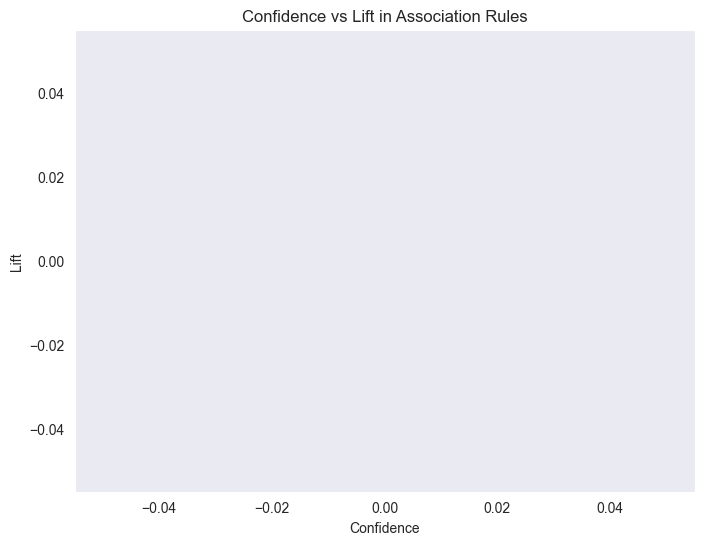

In [13]:
# Scatter plot of confidence vs lift
plt.figure(figsize=(8,6))
plt.scatter(df_ar['confidence'], df_ar['lift'], alpha=0.7, color='b')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift in Association Rules')
plt.grid()
plt.show()

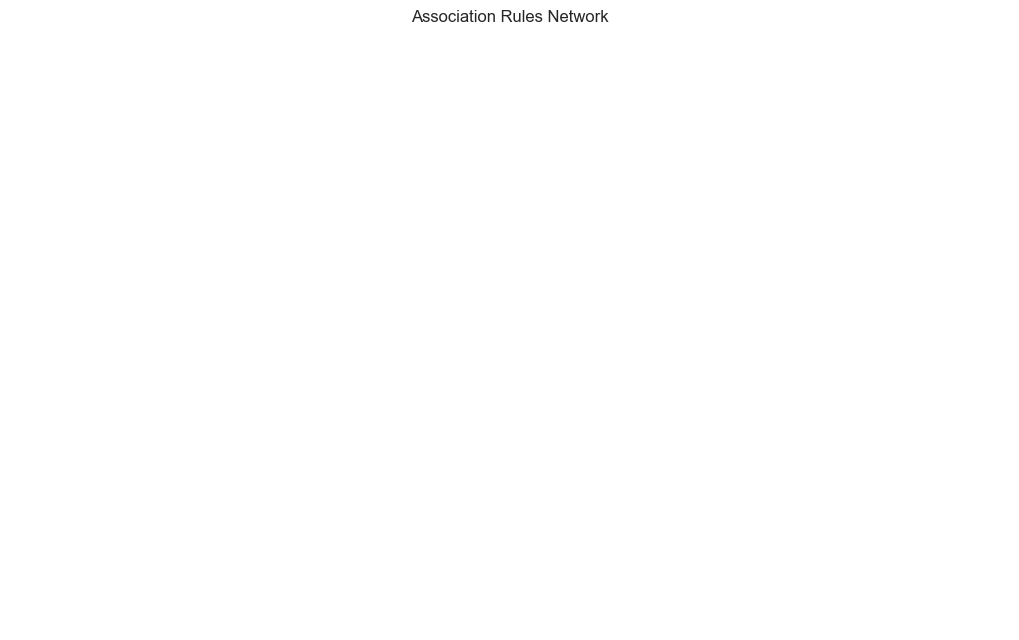

In [14]:
# Visualizing association rules as a network graph
G = nx.DiGraph()
for _, row in df_ar.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['confidence'])
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10)
edge_labels = {(tuple(row['antecedents']), tuple(row['consequents'])): f"{row['confidence']:.2f}"
               for _, row in df_ar.iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network")
plt.show()